<a href="https://colab.research.google.com/github/YashviGupta15/ai-ml-notes/blob/main/NLP_Text_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Practical Lecture 2 — Text Preprocessing Pipeline

## Section 1 — Raw Text Exploration

Before feeding text into machine learning models, we must understand:

- Raw text is messy
- Contains punctuation
- Mixed casing
- Numbers
- Extra spaces
- Special characters

Machine learning models cannot directly understand raw strings.

We must convert text into structured format.

In this section we:

- Import required libraries
- Create noisy text samples
- Observe why preprocessing is needed

In [ ]:
# Basic Libraries
import re
import numpy as np
import pandas as pd

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# Download Required Resources
#nltk.download('punkt')
#nltk.download('stopwords')
#nltk.download('wordnet')

# Raw Text Samples (Noisy Data)

raw_sentences = [
    "I LOVE Machine Learning!!!",
    "   NLP is AMAZING... isn't it???   ",
    "Deep Learning costs $1000 sometimes!!!",
    "AI & ML are transforming the world in 2025!!!",
    "I am learning    NLP     from Masai"
]

print("Raw Sentences:\n")

for sentence in raw_sentences:
    print(sentence)

Raw Sentences:

I LOVE Machine Learning!!!
   NLP is AMAZING... isn't it???   
Deep Learning costs $1000 sometimes!!!
AI & ML are transforming the world in 2025!!!
I am learning    NLP     from Masai


## Observation

Notice the issues in raw text:

- Uppercase vs lowercase inconsistency
- Extra spaces
- Punctuation
- Special characters
- Numbers

Machine learning models cannot interpret these variations correctly.

Example:

"Machine"  
"machine"  

Model may treat them as different words.

This increases vocabulary size unnecessarily.

# Concept Check

1. Why can't we directly feed raw text into ML models?

2. What problem occurs if "Machine" and "machine" are treated differently?

3. Why are extra spaces problematic?

# Section 2 — Basic Text Cleaning Pipeline

Raw text contains:

- Uppercase letters
- Punctuation
- Numbers
- Extra spaces
- Special characters

These variations increase vocabulary size and introduce noise.

We perform:

1. Lowercasing
2. Remove punctuation
3. Remove numbers (optional)
4. Remove extra spaces

Important:

Text preprocessing is **task dependent**  
Sometimes punctuation or numbers are important.

Example:

"5-star rating" → removing number loses meaning

Always think before preprocessing.

In [ ]:
def basic_cleaning(text):

    # Lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove numbers (optional)
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


print("Before Cleaning:\n")

for sentence in raw_sentences:
    print(sentence)

print("\nAfter Cleaning:\n")

cleaned_sentences = [basic_cleaning(sentence) for sentence in raw_sentences]

for sentence in cleaned_sentences:
    print(sentence)

Before Cleaning:

I LOVE Machine Learning!!!
   NLP is AMAZING... isn't it???   
Deep Learning costs $1000 sometimes!!!
AI & ML are transforming the world in 2025!!!
I am learning    NLP     from Masai

After Cleaning:

i love machine learning
nlp is amazing isnt it
deep learning costs sometimes
ai ml are transforming the world in
i am learning nlp from masai


# Observation

After cleaning:

- All words converted to lowercase
- Punctuation removed
- Numbers removed
- Extra spaces removed

This reduces vocabulary size.

Example:

Machine  
machine  

Now treated as same word.

This improves model learning.

# Concept Check

1. Why do we convert text to lowercase?

2. When should we NOT remove numbers?

3. When can punctuation be useful?

# Section 3 — Tokenization

After cleaning text, we still have sentences.

Machine learning models cannot understand sentences directly.

We must break sentences into smaller units called **tokens**.

Example:

Sentence:
"I love machine learning"

Tokens:
["i", "love", "machine", "learning"]

Tokenization is the first structural step in NLP.

Most NLP pipelines begin with tokenization.


In [ ]:
print("Cleaned Sentences:\n")

for sentence in cleaned_sentences:
    print(sentence)

print("\nTokenized Sentences:\n")

tokenized_sentences = [sentence.split() for sentence in cleaned_sentences]

for tokens in tokenized_sentences:
    print(tokens)

Cleaned Sentences:

i love machine learning
nlp is amazing isnt it
deep learning costs sometimes
ai ml are transforming the world in
i am learning nlp from masai

Tokenized Sentences:

['i', 'love', 'machine', 'learning']
['nlp', 'is', 'amazing', 'isnt', 'it']
['deep', 'learning', 'costs', 'sometimes']
['ai', 'ml', 'are', 'transforming', 'the', 'world', 'in']
['i', 'am', 'learning', 'nlp', 'from', 'masai']


In [ ]:
print("NLTK Tokenization:\n")

nltk_tokens = [word_tokenize(sentence) for sentence in cleaned_sentences]

for tokens in nltk_tokens:
    print(tokens)

NLTK Tokenization:

['i', 'love', 'machine', 'learning']
['nlp', 'is', 'amazing', 'isnt', 'it']
['deep', 'learning', 'costs', 'sometimes']
['ai', 'ml', 'are', 'transforming', 'the', 'world', 'in']
['i', 'am', 'learning', 'nlp', 'from', 'masai']


In [ ]:
x = "don't"
x.split()
y = word_tokenize(x)
y

['do', "n't"]

# Observation

Tokenization converts sentences into list of words.

This allows:

- Word counting
- Embedding creation
- Vocabulary building
- Model input preparation

Tokenization is foundational for all NLP tasks.

# Concept Check

1. Why is tokenization required?

2. Why is simple split not always sufficient?

3. What is a token?

# Section 4 — Stop Words, Stemming, Lemmatization

After tokenization, we still have many words that do not add much meaning.

Example:

"I am learning machine learning"

Tokens:

["i", "am", "learning", "machine", "learning"]

Words like:

- is
- am
- the
- and
- of

are called **Stop Words**

These words appear frequently but add little meaning.

Next:

We also normalize words using:

1. Stemming
2. Lemmatization

Example:

learning → learn  
running → run  

This reduces vocabulary size.

This improves model efficiency.

In [ ]:
stop_words = set(stopwords.words('english'))

print("Original Tokens:\n")

for tokens in nltk_tokens:
    print(tokens)

print("\nAfter Stop Word Removal:\n")

tokens_no_stopwords = [
    [word for word in tokens if word not in stop_words]
    for tokens in nltk_tokens
]

for tokens in tokens_no_stopwords:
    print(tokens)

Original Tokens:

['i', 'love', 'machine', 'learning']
['nlp', 'is', 'amazing', 'isnt', 'it']
['deep', 'learning', 'costs', 'sometimes']
['ai', 'ml', 'are', 'transforming', 'the', 'world', 'in']
['i', 'am', 'learning', 'nlp', 'from', 'masai']

After Stop Word Removal:

['love', 'machine', 'learning']
['nlp', 'amazing', 'isnt']
['deep', 'learning', 'costs', 'sometimes']
['ai', 'ml', 'transforming', 'world']
['learning', 'nlp', 'masai']


In [ ]:
stemmer = PorterStemmer()

print("After Stemming:\n")

stemmed_tokens = [
    [stemmer.stem(word) for word in tokens]
    for tokens in tokens_no_stopwords
]

for tokens in stemmed_tokens:
    print(tokens)

After Stemming:

['love', 'machin', 'learn']
['nlp', 'amaz', 'isnt']
['deep', 'learn', 'cost', 'sometim']
['ai', 'ml', 'transform', 'world']
['learn', 'nlp', 'masai']


In [ ]:
lemmatizer = WordNetLemmatizer()

print("After Lemmatization:\n")

lemmatized_tokens = [
    [lemmatizer.lemmatize(word) for word in tokens]
    for tokens in tokens_no_stopwords
]

for tokens in lemmatized_tokens:
    print(tokens)

After Lemmatization:

['love', 'machine', 'learning']
['nlp', 'amazing', 'isnt']
['deep', 'learning', 'cost', 'sometimes']
['ai', 'ml', 'transforming', 'world']
['learning', 'nlp', 'masai']


In [ ]:
from nltk import pos_tag
from nltk.corpus import wordnet
def get_wordnet_pos(tag):

    if tag.startswith('J'):
        return wordnet.ADJ

    elif tag.startswith('V'):
        return wordnet.VERB

    elif tag.startswith('N'):
        return wordnet.NOUN

    elif tag.startswith('R'):
        return wordnet.ADV

    else:
        return wordnet.NOUN

In [ ]:
lemmatizer = WordNetLemmatizer()

pos_lemmatized_tokens = []

for tokens in tokens_no_stopwords:

    pos_tags = pos_tag(tokens)

    lemmatized_sentence = [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in pos_tags
    ]

    pos_lemmatized_tokens.append(lemmatized_sentence)

print("POS Aware Lemmatization:\n")

for tokens in pos_lemmatized_tokens:
    print(tokens)

POS Aware Lemmatization:

['love', 'machine', 'learning']
['nlp', 'amazing', 'isnt']
['deep', 'learning', 'cost', 'sometimes']
['ai', 'ml', 'transforming', 'world']
['learn', 'nlp', 'masai']


In [ ]:
print("Comparison with POS Lemmatization\n")

for i in range(len(tokens_no_stopwords)):

    print("Original:", tokens_no_stopwords[i])
    print("Stemmed:", stemmed_tokens[i])
    print("Lemmatized (Simple):", lemmatized_tokens[i])
    print("POS Lemmatized:", pos_lemmatized_tokens[i])

    print("-"*60)

Comparison with POS Lemmatization

Original: ['love', 'machine', 'learning']
Stemmed: ['love', 'machin', 'learn']
Lemmatized (Simple): ['love', 'machine', 'learning']
POS Lemmatized: ['love', 'machine', 'learning']
------------------------------------------------------------
Original: ['nlp', 'amazing', 'isnt']
Stemmed: ['nlp', 'amaz', 'isnt']
Lemmatized (Simple): ['nlp', 'amazing', 'isnt']
POS Lemmatized: ['nlp', 'amazing', 'isnt']
------------------------------------------------------------
Original: ['deep', 'learning', 'costs', 'sometimes']
Stemmed: ['deep', 'learn', 'cost', 'sometim']
Lemmatized (Simple): ['deep', 'learning', 'cost', 'sometimes']
POS Lemmatized: ['deep', 'learning', 'cost', 'sometimes']
------------------------------------------------------------
Original: ['ai', 'ml', 'transforming', 'world']
Stemmed: ['ai', 'ml', 'transform', 'world']
Lemmatized (Simple): ['ai', 'ml', 'transforming', 'world']
POS Lemmatized: ['ai', 'ml', 'transforming', 'world']
----------------

In [ ]:
words = ["running", "better", "studies"]
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [
    [lemmatizer.lemmatize(i) for i in words]
]
for tokens in lemmatized_tokens:
    print(tokens)

['running', 'better', 'study']


In [ ]:
words = ["running", "better", "studies"]
lemmatizer = WordNetLemmatizer()
pos_tags = pos_tag(words)
lemmatized_words = [ lemmatizer.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags]
print(lemmatized_words)

['run', 'good', 'study']


# Observation

## Stop word removal:

Removes less meaningful words

## Stemming:

Fast but crude

## Lemmatization:

Slower but linguistically correct

Choice depends on task.

## POS-aware lemmatization produces:

- More meaningful root words
- Better linguistic normalization
- Improved embedding quality

This is preferred in production NLP pipelines.

# Concept Check

1. Why remove stop words?

2. Why is stemming sometimes problematic?

3. When should we avoid stop word removal?

4. Why is POS tagging needed before lemmatization?

5. Which is more accurate — stemming or POS lemmatization?

6. When might POS tagging slow down pipeline?

# Section 5 — Full Text Preprocessing Pipeline

So far we implemented:

- Lowercasing
- Cleaning
- Tokenization
- Stop word removal
- POS tagging
- Lemmatization

Now we combine everything into **one reusable function**

Pipeline:

Raw Text  
→ Cleaning  
→ Tokenization  
→ Stop Word Removal  
→ POS Tagging  
→ Lemmatization  

Final Output:

Cleaned tokens ready for NLP models

In [ ]:
def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove numbers(optional: tsak dependent)
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()


    # Tokenization
    tokens = word_tokenize(text)


    # Stopword removal
    tokens = [word for word in tokens if word not in stop_words]


    # POS tagging
    pos_tags = pos_tag(tokens)


    # Lemmatization with POS
    tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in pos_tags
    ]

    return tokens

In [ ]:
processed_sentences = []

for sentence in raw_sentences:

    processed = preprocess_text(sentence)

    processed_sentences.append(processed)

print("Processed Sentences:\n")

for sentence in processed_sentences:
    print(sentence)

Processed Sentences:

['love', 'machine', 'learning']
['nlp', 'amazing', 'isnt']
['deep', 'learning', 'cost', 'sometimes']
['ai', 'ml', 'transforming', 'world']
['learn', 'nlp', 'masai']


In [ ]:
test_sentence = "I am learning NLP and building AI systems in 2025!!!"

print("Original:\n", test_sentence)

print("\nProcessed:\n", preprocess_text(test_sentence))

Original:
 I am learning NLP and building AI systems in 2025!!!

Processed:
 ['learn', 'nlp', 'building', 'ai', 'system']


# Observation

Now we have:

Reusable preprocessing pipeline

This function can:

- Process single sentence
- Process dataset
- Process user input
- Be used in deployment

# Concept Check

1. Why build preprocessing as function?

2. Where will this function be used?

3. What happens if preprocessing is inconsistent?

In [ ]:
import pandas as pd

data = [
    {"review_id": 1, "category": "delivery", "raw_text": "My order arrived 2 days late!!! Very disappointed :("},
    {"review_id": 2, "category": "product_quality", "raw_text": "The phone cover quality is AMAZING, really loved it."},
    {"review_id": 3, "category": "payment", "raw_text": "Payment failed 3 times but money got deducted!!!"},
    {"review_id": 4, "category": "delivery", "raw_text": "Fast delivery, got my package within 24 hours."},
    {"review_id": 5, "category": "customer_service", "raw_text": "Customer support was rude and didn't solve my issue."},
    {"review_id": 6, "category": "product_quality", "raw_text": "Battery backup is too poor, drains in 2 hrs only."},
    {"review_id": 7, "category": "customer_service", "raw_text": "Support team helped me quickly, very happy with service."},
    {"review_id": 8, "category": "payment", "raw_text": "UPI payment successful but app still showed pending status."},
    {"review_id": 9, "category": "delivery", "raw_text": "Packaging was damaged, but product inside was okay."},
    {"review_id": 10, "category": "product_quality", "raw_text": "This laptop is super fast and performance is excellent."},
    {"review_id": 11, "category": "customer_service", "raw_text": "No response from support even after 5 emails."},
    {"review_id": 12, "category": "payment", "raw_text": "Refund has not been credited yet, it's been 7 days now."},
    {"review_id": 13, "category": "delivery", "raw_text": "Delivery boy called twice and delivered on time."},
    {"review_id": 14, "category": "product_quality", "raw_text": "The shirt color faded after one wash. bad quality!"},
    {"review_id": 15, "category": "customer_service", "raw_text": "Excellent support experience, polite and helpful staff."},
    {"review_id": 16, "category": "payment", "raw_text": "Coupon code not working during checkout??"},
    {"review_id": 17, "category": "delivery", "raw_text": "Order tracking link was broken, could not track shipment."},
    {"review_id": 18, "category": "product_quality", "raw_text": "Headphones sound quality is decent for this price."},
    {"review_id": 19, "category": "customer_service", "raw_text": "Agent resolved my complaint in 10 minutes, impressive."},
    {"review_id": 20, "category": "payment", "raw_text": "Double charged on my credit card, please fix this ASAP."},
    {"review_id": 21, "category": "delivery", "raw_text": "Received wrong item instead of the one I ordered."},
    {"review_id": 22, "category": "product_quality", "raw_text": "Shoes are comfortable and fit perfectly."},
    {"review_id": 23, "category": "customer_service", "raw_text": "Worst support ever!!! nobody answered my calls."},
    {"review_id": 24, "category": "payment", "raw_text": "Checkout process was smooth and payment was instant."},
    {"review_id": 25, "category": "delivery", "raw_text": "Package arrived early, really impressed with shipping speed."},
    {"review_id": 26, "category": "product_quality", "raw_text": "Screen has dead pixels, product seems defective."},
    {"review_id": 27, "category": "customer_service", "raw_text": "Thanks to support, my refund issue is finally solved."},
    {"review_id": 28, "category": "payment", "raw_text": "Wallet balance was used incorrectly during payment."},
    {"review_id": 29, "category": "delivery", "raw_text": "Late delivery again... this is the second time this month."},
    {"review_id": 30, "category": "product_quality", "raw_text": "Build quality feels premium and durable."},
    {"review_id": 31, "category": "customer_service", "raw_text": "Support executive was patient and guided me step by step."},
    {"review_id": 32, "category": "payment", "raw_text": "EMI option is missing for this product."},
    {"review_id": 33, "category": "delivery", "raw_text": "Courier status kept changing and package arrived very late."},
    {"review_id": 34, "category": "product_quality", "raw_text": "Camera quality is poor in low light."},
    {"review_id": 35, "category": "customer_service", "raw_text": "Live chat support disconnected suddenly. Very annoying."},
    {"review_id": 36, "category": "payment", "raw_text": "Refund processed successfully, thanks team!"},
    {"review_id": 37, "category": "delivery", "raw_text": "Parcel was left outside the gate without confirmation."},
    {"review_id": 38, "category": "product_quality", "raw_text": "Excellent fabric, soft and comfortable to wear."},
    {"review_id": 39, "category": "customer_service", "raw_text": "Support kept transferring my case to different agents."},
    {"review_id": 40, "category": "payment", "raw_text": "Transaction failed, but bank statement shows deduction."},
    {"review_id": 41, "category": "delivery", "raw_text": "Same-day delivery was promised but order came next day."},
    {"review_id": 42, "category": "product_quality", "raw_text": "Product looks nice in pictures but feels cheap in reality."},
    {"review_id": 43, "category": "customer_service", "raw_text": "Very satisfied with the quick resolution provided by support."},
    {"review_id": 44, "category": "payment", "raw_text": "Payment page froze when I clicked on Pay Now."},
    {"review_id": 45, "category": "delivery", "raw_text": "Box was torn and item seal was already open."},
    {"review_id": 46, "category": "product_quality", "raw_text": "Speaker volume is loud and clear, totally worth it."},
    {"review_id": 47, "category": "customer_service", "raw_text": "No update from support ticket #4589 for 4 days."},
    {"review_id": 48, "category": "payment", "raw_text": "Cashback offer was shown, but I never received it."}
]

df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)
df.head(10)

Dataset Shape: (48, 3)


,review_id,category,raw_text
0,1,delivery,My order arrived 2 days late!!! Very disappoin...
1,2,product_quality,"The phone cover quality is AMAZING, really lov..."
2,3,payment,Payment failed 3 times but money got deducted!!!
3,4,delivery,"Fast delivery, got my package within 24 hours."
4,5,customer_service,Customer support was rude and didn't solve my ...
5,6,product_quality,"Battery backup is too poor, drains in 2 hrs only."
6,7,customer_service,"Support team helped me quickly, very happy wit..."
7,8,payment,UPI payment successful but app still showed pe...
8,9,delivery,"Packaging was damaged, but product inside was ..."
9,10,product_quality,This laptop is super fast and performance is e...


In [ ]:
df["processed_tokens"] = df["raw_text"].apply(preprocess_text)
df[["raw_text", "processed_tokens"]].head(10)

,raw_text,processed_tokens
0,My order arrived 2 days late!!! Very disappoin...,"[order, arrive, day, late, disappointed]"
1,"The phone cover quality is AMAZING, really lov...","[phone, cover, quality, amaze, really, love]"
2,Payment failed 3 times but money got deducted!!!,"[payment, fail, time, money, get, deduct]"
3,"Fast delivery, got my package within 24 hours.","[fast, delivery, get, package, within, hour]"
4,Customer support was rude and didn't solve my ...,"[customer, support, rude, didnt, solve, issue]"
5,"Battery backup is too poor, drains in 2 hrs only.","[battery, backup, poor, drain, hrs]"
6,"Support team helped me quickly, very happy wit...","[support, team, help, quickly, happy, service]"
7,UPI payment successful but app still showed pe...,"[upi, payment, successful, app, still, show, p..."
8,"Packaging was damaged, but product inside was ...","[package, damage, product, inside, okay]"
9,This laptop is super fast and performance is e...,"[laptop, super, fast, performance, excellent]"


In [ ]:
for i in range(8):
    print("Raw Text       :", df.loc[i, "raw_text"])
    print("Processed Text :", df.loc[i, "processed_tokens"])
    print("-" * 80)

Raw Text       : My order arrived 2 days late!!! Very disappointed :(
Processed Text : ['order', 'arrive', 'day', 'late', 'disappointed']
--------------------------------------------------------------------------------
Raw Text       : The phone cover quality is AMAZING, really loved it.
Processed Text : ['phone', 'cover', 'quality', 'amaze', 'really', 'love']
--------------------------------------------------------------------------------
Raw Text       : Payment failed 3 times but money got deducted!!!
Processed Text : ['payment', 'fail', 'time', 'money', 'get', 'deduct']
--------------------------------------------------------------------------------
Raw Text       : Fast delivery, got my package within 24 hours.
Processed Text : ['fast', 'delivery', 'get', 'package', 'within', 'hour']
--------------------------------------------------------------------------------
Raw Text       : Customer support was rude and didn't solve my issue.
Processed Text : ['customer', 'support', 'rude', 

In [ ]:
category_examples = df[["category", "raw_text"]].copy()
category_examples.head()

,category,raw_text
0,delivery,My order arrived 2 days late!!! Very disappoin...
1,product_quality,"The phone cover quality is AMAZING, really lov..."
2,payment,Payment failed 3 times but money got deducted!!!
3,delivery,"Fast delivery, got my package within 24 hours."
4,customer_service,Customer support was rude and didn't solve my ...


In [ ]:
extra_noisy_data = [
    {"review_id": 49, "category": "payment", "raw_text": "PAYMENT failed again!!! txn id 99882 :( pls help"},
    {"review_id": 50, "category": "customer_service", "raw_text": "support not replyinggg... mailed 4 times!!!"},
    {"review_id": 51, "category": "delivery", "raw_text": "order delayed!!! where is my package???"},
    {"review_id": 52, "category": "product_quality", "raw_text": "quality not gud, fabric feels very cheap :/"},
    {"review_id": 53, "category": "payment", "raw_text": "refund pending for 8 days, check www.shophelp.com"},
    {"review_id": 54, "category": "customer_service", "raw_text": "@support team resolved issue quickly, thank you!!"}
]

df_extra = pd.DataFrame(extra_noisy_data)
df = pd.concat([df, df_extra], ignore_index=True)

print("Updated Dataset Shape:", df.shape)
df.tail(10)

Updated Dataset Shape: (54, 4)


,review_id,category,raw_text,processed_tokens
44,45,delivery,Box was torn and item seal was already open.,"[box, torn, item, seal, already, open]"
45,46,product_quality,"Speaker volume is loud and clear, totally wort...","[speaker, volume, loud, clear, totally, worth]"
46,47,customer_service,No update from support ticket #4589 for 4 days.,"[update, support, ticket, day]"
47,48,payment,"Cashback offer was shown, but I never received...","[cashback, offer, show, never, receive]"
48,49,payment,PAYMENT failed again!!! txn id 99882 :( pls help,NaN
49,50,customer_service,support not replyinggg... mailed 4 times!!!,NaN
50,51,delivery,order delayed!!! where is my package???,NaN
51,52,product_quality,"quality not gud, fabric feels very cheap :/",NaN
52,53,payment,"refund pending for 8 days, check www.shophelp.com",NaN
53,54,customer_service,"@support team resolved issue quickly, thank you!!",NaN


# Section 6 — Word2Vec Embeddings

Machine learning models cannot understand words directly.

We must convert words into numbers.

Earlier approaches:

- One-Hot Encoding
- Bag of Words

Problems:

- Sparse representation
- No semantic meaning
- Large dimensionality

Word2Vec solves this problem.

Word2Vec learns:

Words used in similar context  
→ Have similar vector representation

Example:

king → vector  
queen → vector  

king - man + woman ≈ queen

Each word becomes a dense vector.

This helps models understand:

- Similarity
- Context
- Meaning

# Section 6A — Understanding How Word2Vec Learns Embeddings

Before applying Word2Vec on our real dataset, let us first understand the mechanism clearly.

Word2Vec takes:

- tokenized sentences
- builds vocabulary
- learns dense vector for each word

Words appearing in similar context get similar vector representations.

We first demonstrate this on our already processed sentence list.

In [ ]:
from gensim.models import Word2Vec

print("Processed Sentences Used for Initial Demo:\n")

for sentence in processed_sentences[:10]:
    print(sentence)

Processed Sentences Used for Initial Demo:

['love', 'machine', 'learning']
['nlp', 'amazing', 'isnt']
['deep', 'learning', 'cost', 'sometimes']
['ai', 'ml', 'transforming', 'world']
['learn', 'nlp', 'masai']


In [ ]:
demo_w2v_model = Word2Vec(
    sentences=processed_sentences,
    vector_size=10,
    window=3,
    min_count=1,
    workers=4
)

In [ ]:
demo_vocab = list(demo_w2v_model.wv.index_to_key)

print("Vocabulary:\n")
print(demo_vocab)

Vocabulary:

['nlp', 'learning', 'masai', 'learn', 'world', 'transforming', 'ml', 'ai', 'sometimes', 'cost', 'deep', 'isnt', 'amazing', 'machine', 'love']


In [ ]:
word = demo_vocab[0]

print("Word:", word)
print("Vector Shape:", demo_w2v_model.wv[word].shape)
print("Vector:\n", demo_w2v_model.wv[word])

Word: nlp
Vector Shape: (10,)
Vector:
 [-0.00536227  0.00236431  0.0510335   0.09009273 -0.0930295  -0.07116809
  0.06458873  0.08972988 -0.05015428 -0.03763372]


In [ ]:
for word in ["learning", "machine", "nlp", "ai"]:
    if word in demo_vocab:
        print(f"\nSimilar words for '{word}':")
        print(demo_w2v_model.wv.most_similar(word))


Similar words for 'learning':
[('nlp', 0.5436006188392639), ('isnt', 0.35868826508522034), ('masai', 0.32937225699424744), ('love', 0.30433881282806396), ('ai', 0.23243048787117004), ('sometimes', 0.03525320068001747), ('deep', 0.03376543149352074), ('ml', -0.1799871176481247), ('learn', -0.21133741736412048), ('machine', -0.32140395045280457)]

Similar words for 'machine':
[('love', 0.514965832233429), ('amazing', 0.43408331274986267), ('ml', 0.22021201252937317), ('isnt', 0.20956431329250336), ('world', 0.11168702691793442), ('ai', 0.07654326409101486), ('cost', 0.07347215712070465), ('masai', -0.06334745138883591), ('transforming', -0.09995532780885696), ('sometimes', -0.10827529430389404)]

Similar words for 'nlp':
[('learning', 0.5436005592346191), ('deep', 0.43182477355003357), ('sometimes', 0.3792897164821625), ('masai', 0.3004249036312103), ('isnt', 0.22743143141269684), ('learn', 0.10494352877140045), ('ai', -0.1311161071062088), ('ml', -0.1897382140159607), ('love', -0.20557

# Observation

Word2Vec has converted words into dense vectors.

Each word is now represented as a point in high-dimensional space.

Words appearing in similar context tend to get similar vector representations.

# Concept Check

1. What does Word2Vec take as input?

2. What is the output for each word?

3. Why do similar-context words become close in vector space?

# Section 6B — Reusable Word2Vec Training Function

Now that we understand the mechanism, we wrap the training process into a reusable function.

This is useful because:

- same logic can be reused
- easier experimentation
- cleaner pipeline
- easier deployment and scaling

Then we apply it on the real dataset.

In [ ]:
def train_word2vec(tokenized_sentences, vector_size=50, window=3, min_count=1):

    model = Word2Vec(
        sentences=tokenized_sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=4
    )

    return model

In [ ]:
df["processed_tokens"] = df["raw_text"].apply(preprocess_text)

real_sentences = df["processed_tokens"].tolist()

print("Sample Real Dataset Tokens:\n")
for sentence in real_sentences[:5]:
    print(sentence)

Sample Real Dataset Tokens:

['order', 'arrive', 'day', 'late', 'disappointed']
['phone', 'cover', 'quality', 'amaze', 'really', 'love']
['payment', 'fail', 'time', 'money', 'get', 'deduct']
['fast', 'delivery', 'get', 'package', 'within', 'hour']
['customer', 'support', 'rude', 'didnt', 'solve', 'issue']


In [ ]:
real_w2v_model = train_word2vec(real_sentences, vector_size=50, window=3, min_count=1)

In [ ]:
real_vocab = list(real_w2v_model.wv.index_to_key)

print("Vocabulary Size:", len(real_vocab))
print("\nSample Vocabulary:\n", real_vocab[:30])

Vocabulary Size: 210

Sample Vocabulary:
 ['support', 'payment', 'quality', 'package', 'day', 'order', 'refund', 'product', 'delivery', 'time', 'feel', 'excellent', 'show', 'team', 'issue', 'fail', 'late', 'arrive', 'cheap', 'fabric', 'keep', 'step', 'thanks', 'process', 'comfortable', 'item', 'receive', 'resolve', 'agent', 'track']


In [ ]:
words_to_check = ["delivery", "payment", "support", "quality", "refund"]

for word in words_to_check:
    print(f"\nWord: {word}")

    if word in real_vocab:
        print("Vector Shape:", real_w2v_model.wv[word].shape)
        print("Most Similar Words:")
        print(real_w2v_model.wv.most_similar(word))
    else:
        print("Word not found in vocabulary")


Word: delivery
Vector Shape: (50,)
Most Similar Words:
[('receive', 0.3149455189704895), ('chat', 0.3137267231941223), ('link', 0.30618491768836975), ('ever', 0.2877088487148285), ('id', 0.287136048078537), ('helpful', 0.2742912471294403), ('totally', 0.26357054710388184), ('fit', 0.25162261724472046), ('mail', 0.24743153154850006), ('feel', 0.23740042746067047)]

Word: payment
Vector Shape: (50,)
Most Similar Words:
[('service', 0.4168442189693451), ('checkout', 0.3763996660709381), ('soft', 0.2996852397918701), ('performance', 0.2696452736854553), ('option', 0.2585128843784332), ('instead', 0.254940390586853), ('late', 0.22972066700458527), ('clear', 0.22958490252494812), ('sound', 0.2274269312620163), ('premium', 0.22491973638534546)]

Word: support
Vector Shape: (50,)
Most Similar Words:
[('pixel', 0.32795488834381104), ('shoe', 0.32324957847595215), ('email', 0.30141422152519226), ('confirmation', 0.2712448239326477), ('cheap', 0.2711479365825653), ('cashback', 0.2697924375534057

# Observation

The same Word2Vec logic now works on real customer-style text data.

This shows how embeddings move from concept to practical NLP pipeline.

The model learns domain-specific relationships from the dataset itself.

# Concept Check

1. Why wrap Word2Vec training into a function?

2. Why can embeddings differ across domains?

3. Why may results on small datasets be weak?

# Section 7 — Visualizing Word Embeddings using t-SNE

Word2Vec generates high-dimensional vectors.

Example:

delivery → 50 dimensional vector  
payment → 50 dimensional vector  

Humans cannot visualize 50 dimensions.

We use dimensionality reduction:

t-SNE

t-SNE converts:

High dimensional vectors → 2D space

Nearby words in 2D space  
→ Similar semantic meaning

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [ ]:
words = list(real_w2v_model.wv.index_to_key)

word_vectors = real_w2v_model.wv[words]

In [ ]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=5
)

word_vectors_2d = tsne.fit_transform(word_vectors)

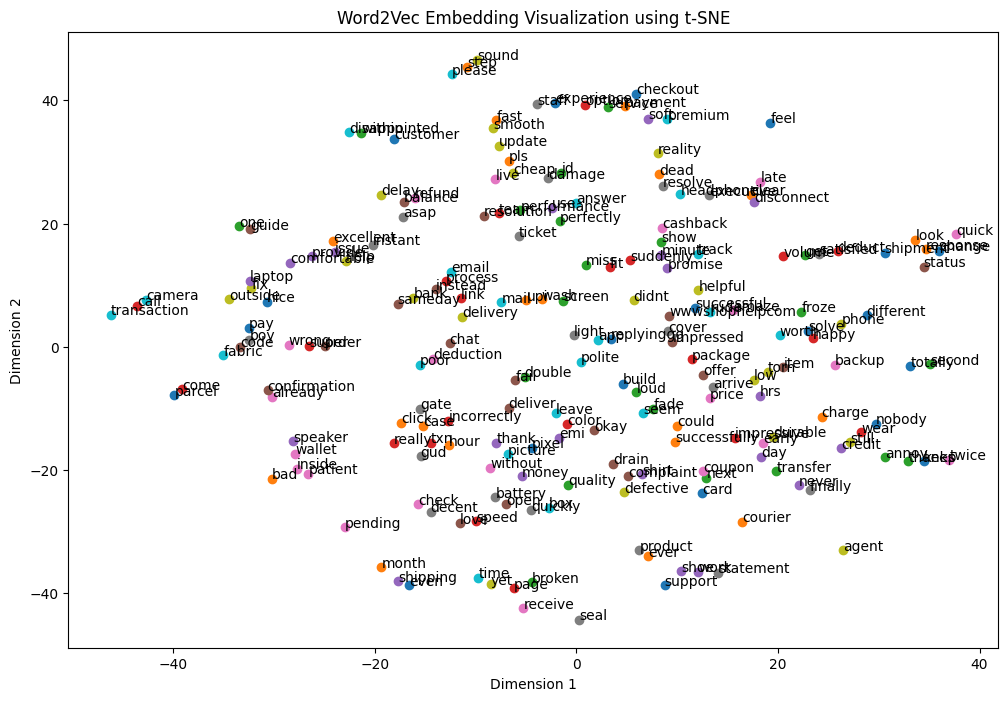

In [ ]:
plt.figure(figsize=(12,8))

for i, word in enumerate(words):

    x, y = word_vectors_2d[i]

    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word, fontsize=10)

plt.title("Word2Vec Embedding Visualization using t-SNE")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()

# Observation

Words that appear in similar context appear closer.

Example clusters:

delivery cluster  
payment cluster  
support cluster  

This shows that Word2Vec captured semantic relationships.

# Concept Check

1. Why do we use t-SNE?

2. Does t-SNE preserve exact distances?

3. Why do some clusters overlap?

# Section 8 — From Word Representation to Document Features

So far, we used **Word2Vec** to learn word embeddings.

Word2Vec helped us understand:

- words can be converted into dense vectors
- semantically similar words may appear close
- vector space can capture contextual relationships

But now we want to solve a new task:

**Sentiment classification**

For classification, we must represent an entire sentence or review as input to a machine learning model.

This raises an important question:

- Word2Vec gives vectors for **words**
- Classifiers need features for **whole documents**

So before training a classifier, we need to discuss:

1. why Word2Vec was useful
2. why Word2Vec alone is not the simplest first choice for sentiment classification
3. why TF-IDF is often used as a strong baseline

## Why Word2Vec alone is not enough here

Word2Vec gives us vectors for words like:

- product
- good
- not

But our classifier must classify the **whole sentence**, not just one word.

A common beginner idea is:

**Take the average of all word vectors in the sentence**

This is simple, but it creates problems:

- word order is lost
- negation becomes weak
- all words are treated almost equally

So:

"This product is good"

and

"This product is not good"

may become too similar after naive averaging.

This is one reason why sequence-aware models become important later.

In [ ]:
sentence_1 = "This product is good"
sentence_2 = "This product is not good"

print("Sentence 1:", sentence_1)
print("Sentence 2:", sentence_2)

# Example only: simple sentence tokenization
example_tokens_1 = preprocess_text(sentence_1)
example_tokens_2 = preprocess_text(sentence_2)

print("Processed Sentence 1:", example_tokens_1)
print("Processed Sentence 2:", example_tokens_2)

Sentence 1: This product is good
Sentence 2: This product is not good
Processed Sentence 1: ['product', 'good']
Processed Sentence 2: ['product', 'good']


# Observation

Word2Vec is very useful for:

- semantic understanding
- similarity
- embedding intuition
- later deep learning models

But for a first classical sentiment classifier, it is not the easiest baseline because:

- it works at word level
- sentence representation is not straightforward
- naive averaging can lose important meaning
- word order is ignored

## Why introduce TF-IDF now?

TF-IDF helps us represent a whole sentence or document as a numerical feature vector.

It tells us:

- which words appear in the review
- which words are important in that review
- which words are common across all reviews and therefore less informative

This makes TF-IDF very useful for classical text classification.

So:

- Word2Vec helps us learn **semantic word representations**
- TF-IDF helps us build **document-level features for classifiers**

## Intuition of TF-IDF

TF = Term Frequency  
How often a word appears in a document

IDF = Inverse Document Frequency  
How rare or informative that word is across the whole dataset

So a word gets higher importance if:

- it appears in a specific document
- but not in every document

Examples:

Words like:
- excellent
- worst
- rude
- defective
- smooth
- delayed

can become strong sentiment signals.

# Concept Check

1. What does Word2Vec mainly represent: words or full documents?

2. Why is naive averaging of word embeddings risky for sentiment classification?

3. Why can TF-IDF work well with Naive Bayes and SVM?

# Section 9 — Preparing a Labeled Sentiment Dataset

To train a sentiment classifier, we need:

- input text
- target label

Here the target label is:

- positive
- negative

This makes sentiment classification a **supervised learning** problem.

We will use a larger customer-feedback style dataset so that:

- the model sees more vocabulary
- train-test split is more stable
- comparison between Naive Bayes and SVM is more meaningful

In [ ]:
import pandas as pd

data = [
    {"text": "My order arrived two days late and the box was damaged.", "sentiment": "negative"},
    {"text": "The delivery was quick and the packaging was excellent.", "sentiment": "positive"},
    {"text": "Payment failed twice and money got deducted from my account.", "sentiment": "negative"},
    {"text": "Customer support resolved my issue very quickly.", "sentiment": "positive"},
    {"text": "The product quality is terrible and feels very cheap.", "sentiment": "negative"},
    {"text": "I really loved the fabric quality and fitting.", "sentiment": "positive"},
    {"text": "The app crashed during checkout and I could not place the order.", "sentiment": "negative"},
    {"text": "Refund was processed smoothly and on time.", "sentiment": "positive"},
    {"text": "The parcel was left outside without my permission.", "sentiment": "negative"},
    {"text": "Amazing product, totally worth the price.", "sentiment": "positive"},
    {"text": "Support team kept transferring my complaint to different agents.", "sentiment": "negative"},
    {"text": "The executive was polite and very helpful.", "sentiment": "positive"},
    {"text": "Delivery status kept changing and the order arrived very late.", "sentiment": "negative"},
    {"text": "The laptop performance is excellent and very fast.", "sentiment": "positive"},
    {"text": "The shirt color faded after the first wash.", "sentiment": "negative"},
    {"text": "Very satisfied with the build quality of the headphones.", "sentiment": "positive"},
    {"text": "I never received the cashback that was promised.", "sentiment": "negative"},
    {"text": "Checkout was easy and payment was successful instantly.", "sentiment": "positive"},
    {"text": "The screen has dead pixels and looks defective.", "sentiment": "negative"},
    {"text": "The shoes are comfortable and fit perfectly.", "sentiment": "positive"},
    {"text": "No response from support even after multiple emails.", "sentiment": "negative"},
    {"text": "The refund issue was solved and I am happy now.", "sentiment": "positive"},
    {"text": "I received the wrong item instead of what I ordered.", "sentiment": "negative"},
    {"text": "The camera quality is very good in daylight.", "sentiment": "positive"},
    {"text": "Transaction failed but the bank statement shows deduction.", "sentiment": "negative"},
    {"text": "Great service, my order arrived earlier than expected.", "sentiment": "positive"},
    {"text": "The packaging was torn and the seal was already open.", "sentiment": "negative"},
    {"text": "The support staff guided me step by step.", "sentiment": "positive"},
    {"text": "This is the second time my delivery got delayed.", "sentiment": "negative"},
    {"text": "The speaker volume is loud and clear.", "sentiment": "positive"},
    {"text": "Coupon code was not working during checkout.", "sentiment": "negative"},
    {"text": "I am impressed with the product finish and premium feel.", "sentiment": "positive"},
    {"text": "The courier never called before attempting delivery.", "sentiment": "negative"},
    {"text": "Excellent support experience, very fast resolution.", "sentiment": "positive"},
    {"text": "The app showed pending status even after successful payment.", "sentiment": "negative"},
    {"text": "The parcel arrived safely and everything was intact.", "sentiment": "positive"},
    {"text": "The fabric feels rough and uncomfortable.", "sentiment": "negative"},
    {"text": "Very happy with the smooth ordering experience.", "sentiment": "positive"},
    {"text": "The product stopped working after two days.", "sentiment": "negative"},
    {"text": "Battery backup is impressive and lasts all day.", "sentiment": "positive"},
    {"text": "Refund is still pending after seven days.", "sentiment": "negative"},
    {"text": "The customer service agent was patient and kind.", "sentiment": "positive"},
    {"text": "The item looks good in pictures but feels low quality in reality.", "sentiment": "negative"},
    {"text": "Very pleased with the fast shipping speed.", "sentiment": "positive"},
    {"text": "The wrong size was delivered to me.", "sentiment": "negative"},
    {"text": "The replacement process was easy and hassle free.", "sentiment": "positive"},
    {"text": "Live chat disconnected suddenly and nobody came back.", "sentiment": "negative"},
    {"text": "The order tracking system worked perfectly.", "sentiment": "positive"},
    {"text": "I was charged twice for the same transaction.", "sentiment": "negative"},
    {"text": "The product feels durable and well made.", "sentiment": "positive"},
    {"text": "The seller ignored my complaint completely.", "sentiment": "negative"},
    {"text": "I loved the packaging and presentation.", "sentiment": "positive"},
    {"text": "The return request was rejected unfairly.", "sentiment": "negative"},
    {"text": "The quality is excellent for this price range.", "sentiment": "positive"},
    {"text": "The box arrived crushed and damaged.", "sentiment": "negative"},
    {"text": "Very satisfied with the overall shopping experience.", "sentiment": "positive"},
    {"text": "The customer care number was unreachable.", "sentiment": "negative"},
    {"text": "The parcel reached on the promised date.", "sentiment": "positive"},
    {"text": "This product is not worth buying.", "sentiment": "negative"},
    {"text": "I would definitely recommend this product to others.", "sentiment": "positive"},
    {"text": "The app freezes whenever I try to make payment.", "sentiment": "negative"},
    {"text": "The refund was credited without any delay.", "sentiment": "positive"},
    {"text": "Terrible support, nobody listened to my problem.", "sentiment": "negative"},
    {"text": "The sound quality is crisp and enjoyable.", "sentiment": "positive"},
    {"text": "Delivery was promised today but came the next day.", "sentiment": "negative"},
    {"text": "The fit is perfect and very comfortable.", "sentiment": "positive"},
    {"text": "This was a disappointing purchase overall.", "sentiment": "negative"},
    {"text": "The material feels soft and premium.", "sentiment": "positive"},
    {"text": "I am unhappy with the poor battery performance.", "sentiment": "negative"},
    {"text": "Everything worked exactly as expected.", "sentiment": "positive"},
    {"text": "The order status was confusing and misleading.", "sentiment": "negative"},
    {"text": "Fantastic experience from order to delivery.", "sentiment": "positive"},
    {"text": "The product arrived defective and unusable.", "sentiment": "negative"},
    {"text": "I am very happy with my purchase.", "sentiment": "positive"},
    {"text": "The website is slow and checkout is frustrating.", "sentiment": "negative"},
    {"text": "Great value for money and very reliable.", "sentiment": "positive"},
    {"text": "Support responded too late to be useful.", "sentiment": "negative"},
    {"text": "The exchange was completed smoothly.", "sentiment": "positive"},
    {"text": "The build quality feels weak and fragile.", "sentiment": "negative"},
    {"text": "I had a wonderful experience with this order.", "sentiment": "positive"}
]

df_sentiment = pd.DataFrame(data)

print("Dataset Shape:", df_sentiment.shape)
print("\nClass Distribution:\n")
print(df_sentiment["sentiment"].value_counts())

df_sentiment.head(10)

Dataset Shape: (80, 2)

Class Distribution:

sentiment
negative    40
positive    40
Name: count, dtype: int64


,text,sentiment
0,My order arrived two days late and the box was...,negative
1,The delivery was quick and the packaging was e...,positive
2,Payment failed twice and money got deducted fr...,negative
3,Customer support resolved my issue very quickly.,positive
4,The product quality is terrible and feels very...,negative
5,I really loved the fabric quality and fitting.,positive
6,The app crashed during checkout and I could no...,negative
7,Refund was processed smoothly and on time.,positive
8,The parcel was left outside without my permiss...,negative
9,"Amazing product, totally worth the price.",positive


In [ ]:
print("Sample Positive Reviews:\n")
print(df_sentiment[df_sentiment["sentiment"] == "positive"]["text"].head(5).to_list())

print("\nSample Negative Reviews:\n")
print(df_sentiment[df_sentiment["sentiment"] == "negative"]["text"].head(5).to_list())

Sample Positive Reviews:

['The delivery was quick and the packaging was excellent.', 'Customer support resolved my issue very quickly.', 'I really loved the fabric quality and fitting.', 'Refund was processed smoothly and on time.', 'Amazing product, totally worth the price.']

Sample Negative Reviews:

['My order arrived two days late and the box was damaged.', 'Payment failed twice and money got deducted from my account.', 'The product quality is terrible and feels very cheap.', 'The app crashed during checkout and I could not place the order.', 'The parcel was left outside without my permission.']


# Observation

Now we have a labeled dataset:

- `text` is the input
- `sentiment` is the output

This dataset can now be used to train a classifier.

Because the dataset is larger than a tiny toy example, it gives:

- richer vocabulary
- better coverage of sentiment words
- more meaningful model comparison

# Concept Check

1. Why do we need labels for sentiment classification?

2. What makes this a supervised learning problem?

3. Why is a slightly larger dataset better than a tiny toy dataset here?

# Section 10 — Preprocessing for Sentiment Classification

Preprocessing is **task dependent**.

Earlier, we used a general preprocessing pipeline.

But for sentiment classification, some stop words such as:

- not
- no
- never

are actually important.

Example:

- "This product is good"
- "This product is not good"

If we remove **not**, both sentences become too similar.

So for sentiment classification, we slightly modify preprocessing:

- lowercase
- remove punctuation
- remove numbers
- tokenize
- remove most stop words
- **keep negation words**
- apply POS-aware lemmatization

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import re

# Base stopword set
stop_words_base = set(stopwords.words('english'))

# Keep negation-related words
negation_words = {"not", "no", "nor", "never", "neither", "none"}

# Remove these from stopword list
stop_words_sentiment = stop_words_base - negation_words

print("Negation words kept in vocabulary:")
print(negation_words)

Negation words kept in vocabulary:
{'nor', 'not', 'neither', 'no', 'none', 'never'}


In [ ]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [ ]:
lemmatizer = WordNetLemmatizer()

def preprocess_for_sentiment(text):

    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords but keep negation words
    tokens = [word for word in tokens if word not in stop_words_sentiment]

    # POS tagging
    pos_tags = pos_tag(tokens)

    # POS-aware lemmatization
    tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in pos_tags
    ]

    return tokens

In [ ]:
example_1 = "This product is good"
example_2 = "This product is not good"

print("Example 1:", example_1)
print("Processed:", preprocess_for_sentiment(example_1))

print("\nExample 2:", example_2)
print("Processed:", preprocess_for_sentiment(example_2))

Example 1: This product is good
Processed: ['product', 'good']

Example 2: This product is not good
Processed: ['product', 'not', 'good']


In [ ]:
df_sentiment["processed_tokens"] = df_sentiment["text"].apply(preprocess_for_sentiment)
df_sentiment["processed_text"] = df_sentiment["processed_tokens"].apply(lambda x: " ".join(x))

df_sentiment[["text", "processed_tokens", "processed_text", "sentiment"]].head(10)

,text,processed_tokens,processed_text,sentiment
0,My order arrived two days late and the box was...,"[order, arrive, two, day, late, box, damage]",order arrive two day late box damage,negative
1,The delivery was quick and the packaging was e...,"[delivery, quick, packaging, excellent]",delivery quick packaging excellent,positive
2,Payment failed twice and money got deducted fr...,"[payment, fail, twice, money, get, deducted, a...",payment fail twice money get deducted account,negative
3,Customer support resolved my issue very quickly.,"[customer, support, resolve, issue, quickly]",customer support resolve issue quickly,positive
4,The product quality is terrible and feels very...,"[product, quality, terrible, feel, cheap]",product quality terrible feel cheap,negative
5,I really loved the fabric quality and fitting.,"[really, love, fabric, quality, fitting]",really love fabric quality fitting,positive
6,The app crashed during checkout and I could no...,"[app, crash, checkout, could, not, place, order]",app crash checkout could not place order,negative
7,Refund was processed smoothly and on time.,"[refund, process, smoothly, time]",refund process smoothly time,positive
8,The parcel was left outside without my permiss...,"[parcel, leave, outside, without, permission]",parcel leave outside without permission,negative
9,"Amazing product, totally worth the price.","[amaze, product, totally, worth, price]",amaze product totally worth price,positive


# Observation

The preprocessing pipeline is now adapted for sentiment classification.

Important sentiment words like:

- not
- no
- never

are preserved.

This helps the classifier distinguish between positive and negative meaning more accurately.

# Concept Check

1. Why should preprocessing change depending on task?

2. Why is keeping negation important in sentiment analysis?

3. What is the role of POS-aware lemmatization here?

# Section 11 — TF-IDF Feature Extraction

Now that our text has been cleaned for sentiment classification, we must convert each review into numbers.

Classical machine learning models like:

- Naive Bayes
- SVM

cannot directly work on raw text.

So we use **TF-IDF**.

TF-IDF stands for:

- **TF** = Term Frequency
- **IDF** = Inverse Document Frequency

It gives higher importance to words that:

- appear in a document
- but are not too common across all documents

This helps highlight informative words such as:

- excellent
- terrible
- refund
- damaged
- helpful
- frustrating

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

X_text = df_sentiment["processed_text"]
y = df_sentiment["sentiment"]

print("Sample processed reviews:\n")
for i in range(5):
    print(f"Review {i+1}: {X_text.iloc[i]}")
    print(f"Label   : {y.iloc[i]}")
    print("-" * 70)

Sample processed reviews:

Review 1: order arrive two day late box damage
Label   : negative
----------------------------------------------------------------------
Review 2: delivery quick packaging excellent
Label   : positive
----------------------------------------------------------------------
Review 3: payment fail twice money get deducted account
Label   : negative
----------------------------------------------------------------------
Review 4: customer support resolve issue quickly
Label   : positive
----------------------------------------------------------------------
Review 5: product quality terrible feel cheap
Label   : negative
----------------------------------------------------------------------


In [ ]:
tfidf_vectorizer = TfidfVectorizer()

X_tfidf = tfidf_vectorizer.fit_transform(X_text)

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (80, 234)


In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))
print("\nSample features:\n")
print(feature_names[:40])

Number of TF-IDF features: 234

Sample features:

['account' 'agent' 'already' 'amaze' 'app' 'arrive' 'attempt' 'back'
 'backup' 'bank' 'battery' 'box' 'build' 'buying' 'call' 'camera' 'care'
 'cashback' 'change' 'charge' 'chat' 'cheap' 'checkout' 'clear' 'code'
 'color' 'come' 'comfortable' 'complaint' 'complete' 'completely'
 'confuse' 'could' 'coupon' 'courier' 'crash' 'credit' 'crisp' 'crushed'
 'customer']


In [ ]:
tfidf_sample_df = pd.DataFrame(
    X_tfidf[:5].toarray(),
    columns=feature_names
)

tfidf_sample_df.iloc[:, :15]

,account,agent,already,amaze,app,arrive,attempt,back,backup,bank,battery,box,build,buying,call
0,0.000000,0.0,0.0,0.0,0.0,0.336097,0.0,0.0,0.0,0.0,0.0,0.418675,0.0,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.408658,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [ ]:
doc_index = 0

doc_vector = X_tfidf[doc_index].toarray().flatten()
non_zero_indices = doc_vector.nonzero()[0]

top_features = sorted(
    [(feature_names[i], doc_vector[i]) for i in non_zero_indices],
    key=lambda x: x[1],
    reverse=True
)

print("Original Review:")
print(df_sentiment.loc[doc_index, "text"])

print("\nProcessed Review:")
print(df_sentiment.loc[doc_index, "processed_text"])

print("\nTop TF-IDF Features:")
for word, score in top_features:
    print(f"{word:15s} -> {score:.4f}")

Original Review:
My order arrived two days late and the box was damaged.

Processed Review:
order arrive two day late box damage

Top TF-IDF Features:
box             -> 0.4187
damage          -> 0.4187
two             -> 0.4187
late            -> 0.3906
day             -> 0.3511
arrive          -> 0.3361
order           -> 0.2920


# Observation

TF-IDF converts each review into a numerical feature vector.

Important words get higher weight.

This means the classifier can now learn patterns such as:

- positive reviews often contain words like excellent, smooth, reliable
- negative reviews often contain words like damaged, failed, terrible, frustrating

So TF-IDF turns text into structured input for classical ML.

# Concept Check

1. Why do we need TF-IDF after preprocessing?

2. What kind of words get high TF-IDF scores?

3. Why do common words across many documents get lower importance?

# Section 12 — Training Naive Bayes and SVM Classifiers

Now that we have TF-IDF features, we can train machine learning models.

We will train:

1. **Multinomial Naive Bayes**
2. **Support Vector Machine (Linear SVM)**

Why these two?

- Naive Bayes is simple and fast
- SVM is often very strong for text classification

This will help us compare two classical NLP baselines on the same sentiment dataset.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

Training shape: (64, 234)
Testing shape : (16, 234)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [ ]:
y_pred_nb = nb_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

print("Naive Bayes Predictions:\n", y_pred_nb[:10])
print("\nSVM Predictions:\n", y_pred_svm[:10])

Naive Bayes Predictions:
 ['negative' 'positive' 'positive' 'positive' 'negative' 'positive'
 'positive' 'positive' 'negative' 'negative']

SVM Predictions:
 ['negative' 'positive' 'negative' 'negative' 'negative' 'positive'
 'positive' 'positive' 'positive' 'negative']


In [ ]:
sample_reviews = [
    "The product quality is amazing and I am very happy",
    "Delivery was late and the packaging was damaged",
    "Customer support solved my issue quickly",
    "Payment failed and refund is still pending",
    "This is not a good purchase"
]

sample_reviews_processed = [" ".join(preprocess_for_sentiment(text)) for text in sample_reviews]
sample_reviews_tfidf = tfidf_vectorizer.transform(sample_reviews_processed)

sample_pred_nb = nb_model.predict(sample_reviews_tfidf)
sample_pred_svm = svm_model.predict(sample_reviews_tfidf)

for i, review in enumerate(sample_reviews):
    print(f"Review: {review}")
    print(f"Processed: {sample_reviews_processed[i]}")
    print(f"Naive Bayes Prediction: {sample_pred_nb[i]}")
    print(f"SVM Prediction         : {sample_pred_svm[i]}")
    print("-" * 80)

Review: The product quality is amazing and I am very happy
Processed: product quality amaze happy
Naive Bayes Prediction: positive
SVM Prediction         : positive
--------------------------------------------------------------------------------
Review: Delivery was late and the packaging was damaged
Processed: delivery late packaging damage
Naive Bayes Prediction: negative
SVM Prediction         : negative
--------------------------------------------------------------------------------
Review: Customer support solved my issue quickly
Processed: customer support solve issue quickly
Naive Bayes Prediction: positive
SVM Prediction         : positive
--------------------------------------------------------------------------------
Review: Payment failed and refund is still pending
Processed: payment fail refund still pending
Naive Bayes Prediction: negative
SVM Prediction         : negative
--------------------------------------------------------------------------------
Review: This is not

# Observation

Both models can now predict sentiment from text.

Naive Bayes:

- simple
- fast
- strong baseline for text

SVM:

- often more powerful
- works very well on sparse TF-IDF features

Now we can compare their performance using proper evaluation metrics.

# Concept Check

1. Why do we split the dataset into training and testing sets?

2. Why is SVM often strong for text classification?

3. Why is Naive Bayes still useful even though it is simple?

# Section 13 — Evaluating Naive Bayes and SVM

After training a classifier, we must measure how well it performs on unseen data.

We will use:

1. **Accuracy**
2. **Confusion Matrix**
3. **Classification Report**

Why these?

- Accuracy gives overall correctness
- Confusion Matrix shows where mistakes happen
- Classification Report gives precision, recall, and F1-score

In [ ]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, y_pred_nb)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("Naive Bayes Accuracy :", round(nb_accuracy, 4))
print("SVM Accuracy         :", round(svm_accuracy, 4))

Naive Bayes Accuracy : 0.625
SVM Accuracy         : 0.4375


In [ ]:
from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=["positive", "negative"])
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=["positive", "negative"])

print("Naive Bayes Confusion Matrix:\n")
print(cm_nb)

print("\nSVM Confusion Matrix:\n")
print(cm_svm)

Naive Bayes Confusion Matrix:

[[6 2]
 [4 4]]

SVM Confusion Matrix:

[[4 4]
 [5 3]]


In [ ]:
cm_nb_df = pd.DataFrame(
    cm_nb,
    index=["Actual Positive", "Actual Negative"],
    columns=["Predicted Positive", "Predicted Negative"]
)

cm_svm_df = pd.DataFrame(
    cm_svm,
    index=["Actual Positive", "Actual Negative"],
    columns=["Predicted Positive", "Predicted Negative"]
)

print("Naive Bayes Confusion Matrix:\n")
display(cm_nb_df)

print("\nSVM Confusion Matrix:\n")
display(cm_svm_df)

Naive Bayes Confusion Matrix:



,Predicted Positive,Predicted Negative
Actual Positive,6,2
Actual Negative,4,4



SVM Confusion Matrix:



,Predicted Positive,Predicted Negative
Actual Positive,4,4
Actual Negative,5,3


In [ ]:
from sklearn.metrics import classification_report

print("Naive Bayes Classification Report:\n")
print(classification_report(y_test, y_pred_nb))

print("\nSVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

Naive Bayes Classification Report:

              precision    recall  f1-score   support

    negative       0.67      0.50      0.57         8
    positive       0.60      0.75      0.67         8

    accuracy                           0.62        16
   macro avg       0.63      0.62      0.62        16
weighted avg       0.63      0.62      0.62        16


SVM Classification Report:

              precision    recall  f1-score   support

    negative       0.43      0.38      0.40         8
    positive       0.44      0.50      0.47         8

    accuracy                           0.44        16
   macro avg       0.44      0.44      0.44        16
weighted avg       0.44      0.44      0.44        16



# Observation

Accuracy gives one overall score, but it does not tell the full story.

The confusion matrix shows:

- how many positive reviews were classified correctly
- how many negative reviews were classified correctly
- where the model is making mistakes

This is important because two models can have similar accuracy but different mistake patterns.

# Concept Check

1. Why is accuracy alone not enough?

2. What does the confusion matrix tell us?

3. If a negative review is predicted as positive, what kind of error is that?

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM"],
    "Accuracy": [nb_accuracy, svm_accuracy]
})

comparison_df

,Model,Accuracy
0,Naive Bayes,0.6250
1,SVM,0.4375
